In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [81]:
from google.colab import drive

drive.mount('/content/drive')
dt = pd.read_csv('/content/drive/MyDrive/DateFruit_Dataset.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [82]:
# Load Dataset
dt.head()

,AREA,PERIMETER,MAJOR_AXIS,MINOR_AXIS,ECCENTRICITY,EQDIASQ,SOLIDITY,CONVEX_AREA,EXTENT,ASPECT_RATIO,...,KurtosisRR,KurtosisRG,KurtosisRB,EntropyRR,EntropyRG,EntropyRB,ALLdaub4RR,ALLdaub4RG,ALLdaub4RB,Class
0,422163,2378.908,837.8484,645.6693,0.6373,733.1539,0.9947,424428,0.7831,1.2976,...,3.2370,2.9574,4.2287,-59191263232,-50714214400,-39922372608,58.7255,54.9554,47.8400,BERHI
1,338136,2085.144,723.8198,595.2073,0.5690,656.1464,0.9974,339014,0.7795,1.2161,...,2.6228,2.6350,3.1704,-34233065472,-37462601728,-31477794816,50.0259,52.8168,47.8315,BERHI
2,526843,2647.394,940.7379,715.3638,0.6494,819.0222,0.9962,528876,0.7657,1.3150,...,3.7516,3.8611,4.7192,-93948354560,-74738221056,-60311207936,65.4772,59.2860,51.9378,BERHI
3,416063,2351.210,827.9804,645.2988,0.6266,727.8378,0.9948,418255,0.7759,1.2831,...,5.0401,8.6136,8.2618,-32074307584,-32060925952,-29575010304,43.3900,44.1259,41.1882,BERHI
4,347562,2160.354,763.9877,582.8359,0.6465,665.2291,0.9908,350797,0.7569,1.3108,...,2.7016,2.9761,4.4146,-39980974080,-35980042240,-25593278464,52.7743,50.9080,42.6666,BERHI


In [83]:
# Partition into Multi-Features & Label
X = dt.drop(columns='Class')
y = dt['Class']

In [84]:
# Analyze Details
print(X.shape)
print("\n")
print(X.info)
print("\n")
print(X.isnull().sum())

(898, 34)


<bound method DataFrame.info of        AREA  PERIMETER  MAJOR_AXIS  MINOR_AXIS  ECCENTRICITY   EQDIASQ  \
0    422163  2378.9080    837.8484    645.6693        0.6373  733.1539   
1    338136  2085.1440    723.8198    595.2073        0.5690  656.1464   
2    526843  2647.3940    940.7379    715.3638        0.6494  819.0222   
3    416063  2351.2100    827.9804    645.2988        0.6266  727.8378   
4    347562  2160.3540    763.9877    582.8359        0.6465  665.2291   
..      ...        ...         ...         ...           ...       ...   
893  255403  1925.3650    691.8453    477.1796        0.7241  570.2536   
894  365924  2664.8230    855.4633    551.5447        0.7644  682.5752   
895  254330  1926.7360    747.4943    435.6219        0.8126  569.0545   
896  238955  1906.2679    716.6485    441.8297        0.7873  551.5859   
897  343792  2289.2720    823.8438    534.7757        0.7607  661.6113   

     SOLIDITY  CONVEX_AREA  EXTENT  ASPECT_RATIO  ...  SkewRB  Kurt

In [85]:
# Analyze output
print(y.shape)
print("\n")
print(y.info)
print("\n")
print(y.isnull().sum())

(898,)


<bound method Series.info of 0      BERHI
1      BERHI
2      BERHI
3      BERHI
4      BERHI
       ...  
893    SOGAY
894    SOGAY
895    SOGAY
896    SOGAY
897    SOGAY
Name: Class, Length: 898, dtype: object>


0


In [86]:
# Count of Output Cetagories
print(y.value_counts())

Class
DOKOL     204
SAFAVI    199
ROTANA    166
DEGLET     98
SOGAY      94
IRAQI      72
BERHI      65
Name: count, dtype: int64


In [87]:
# Label Encoding on Output Cetagories
encode = LabelEncoder()

y_encode = encode.fit_transform(y)
y_encode

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,

In [88]:
# Split into Train-Test
X_train, X_test, y_encode_train, y_encode_test = train_test_split(
    X, y_encode,
    test_size=0.2,
    random_state=42
)

In [89]:
X_train.shape

(718, 34)

In [90]:
# Scale the dataset
scaler = StandardScaler()

X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.fit_transform(X_test)

In [91]:
# Convert into Tensor Data Type
X_train_tensor = torch.tensor(X_train_scale, dtype=torch.float32)
y_train_tensor = torch.tensor(y_encode_train, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_scale, dtype=torch.float32)
y_test_tensor = torch.tensor(y_encode_test, dtype=torch.long)

In [92]:
# Check Dtype
print(X_train_tensor.dtype)

print(y_encode_test.dtype)

torch.float32
int64


In [93]:
# Use Tensor Dataset model and process to DataLoader model
training_dt = TensorDataset(X_train_tensor, y_train_tensor)
testing_dt = TensorDataset(X_test_tensor, y_test_tensor)


In [94]:
training_loader = DataLoader(training_dt, batch_size=32, shuffle=True)
testing_loader = DataLoader(testing_dt, batch_size=32)

In [95]:
# Create ANN model
class ANN(nn.Module):
  def __init__(self):
    super(ANN, self).__init__()
# Design the Architecture
    self.model = nn.Sequential(
        # 1st Layer
        nn.Linear(X.shape[1], 64),
        nn.ReLU(),
        # 2nd Layer
        nn.Linear(64, 64),
        nn.ReLU(),
        # Last Layer
        nn.Linear(64, X.shape[1])
    )
# Design Forward propagation
  def forward(self, x):
    return self.model(x)

In [96]:
# Call the ANN model
model = ANN()

# Initialize loss fnx
criterion = nn.CrossEntropyLoss()

# Initialize Optimizers
optimizer = optim.Adam(model.parameters(), lr=0.001)   # Param=w, b & lr=Learning Rate

In [97]:
# Train the ANN Model
epochs = 100
training_losses = []

for epoch in range(epochs):
  # Initialize Training Status
  model.train()

  # Default loss val, calc. total loss
  total_loss = 0.0

  #Loop in training_loader and feed ANN model in batches
  for Xb, yb in training_loader:
    # Refresh Gradient val every time
    optimizer.zero_grad()

    # Forward Propagation|
    predict = model(Xb)
    # Calculate Loss
    loss = criterion(predict, yb)
    # BackPropagation
    loss.backward()
    # Apply Optimizer, to update parameters
    optimizer.step()

    #Calculate Total loss
    total_loss += loss.item()

  # Calculate Avg.Loss of every epoch
  avg_loss = total_loss/len(training_loader)
  training_losses.append(avg_loss)

  print(f"Epoch: {epoch+1}/{epochs} ----> Loss: {avg_loss}")

Epoch: 1/100 ----> Loss: 2.952831102454144
Epoch: 2/100 ----> Loss: 1.625217344449914
Epoch: 3/100 ----> Loss: 0.864882406981095
Epoch: 4/100 ----> Loss: 0.6177857401578323
Epoch: 5/100 ----> Loss: 0.5112972933313121
Epoch: 6/100 ----> Loss: 0.459026751310929
Epoch: 7/100 ----> Loss: 0.41099759158880816
Epoch: 8/100 ----> Loss: 0.3634818908960923
Epoch: 9/100 ----> Loss: 0.33800439730934473
Epoch: 10/100 ----> Loss: 0.3048406230366748
Epoch: 11/100 ----> Loss: 0.29269223368686176
Epoch: 12/100 ----> Loss: 0.2714126874571261
Epoch: 13/100 ----> Loss: 0.2540092092493306
Epoch: 14/100 ----> Loss: 0.24641877736734308
Epoch: 15/100 ----> Loss: 0.23089161094116128
Epoch: 16/100 ----> Loss: 0.21838384737139163
Epoch: 17/100 ----> Loss: 0.20633323328650516
Epoch: 18/100 ----> Loss: 0.19920702570158502
Epoch: 19/100 ----> Loss: 0.18361717251979787
Epoch: 20/100 ----> Loss: 0.18792742004861002
Epoch: 21/100 ----> Loss: 0.18154742746897365
Epoch: 22/100 ----> Loss: 0.1778109980666119
Epoch: 23/10

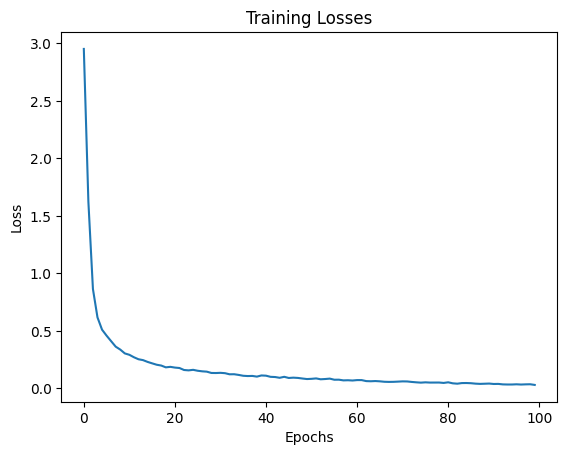

In [98]:
# Plot the Decreasing Loss
loss_dt = pd.DataFrame({
    "Training_loss": training_losses
})

plt.plot(
    loss_dt["Training_loss"],
    label="Training_loss"
)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Losses")

plt.savefig(
    "/content/drive/MyDrive/training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [99]:
# Model Evaluation

#Initialize Evaluation state
model.eval()
# Default Total Prediction count & Correct prediction count
total_pred = 0
corr_pred = 0

#Apply no gradient calculation
with torch.no_grad():
  for Xb, yb in testing_loader:
    pred = model(Xb)
    # This prediction will return some tensor val as 0.2, 0.3, 1.3, 2.0, 1.5
    # We want the maximum val as best prediction val
    # Now we want the right category as Output, so we have to take the maxVal's Index No., not the maxVal
    _, predCategory = torch.max(pred, 1) # '_' uses to hide, because maxVal not want, only index(1) want

    corr_pred += (predCategory == yb).sum().item()
    total_pred += yb.size(0)

print(f"Accuracy Score: ", (corr_pred/total_pred) * 100)

Accuracy Score:  95.55555555555556


In [100]:
# Applying PCA for better prediction
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X_train_scale)

PCA()

In [101]:
# Calculate cumulative explained variance to find opt. dimension
cum_var = np.cumsum(pca.explained_variance_ratio_)

print(cum_var)

[0.40992337 0.63977903 0.75365532 0.81622661 0.86614124 0.90293243
 0.92967453 0.94795942 0.96275643 0.97069534 0.9771551  0.98199358
 0.98599424 0.98940121 0.99210511 0.99418288 0.99555702 0.99686205
 0.99802425 0.99877119 0.99929071 0.99965875 0.99981577 0.99992687
 0.99996448 0.99998517 0.99999465 0.99999787 0.99999976 0.99999996
 1.         1.         1.         1.        ]


In [102]:
# Optimal Dimension starts from 6D
pca_model = PCA(n_components=8)

X_train_pca = pca_model.fit_transform(X_train_scale)
X_test_pca = pca_model.fit_transform(X_test_scale)

In [103]:
print("Before PCA input dataset dimenson:", X_train_scale.shape)
print("After PCA input dataset dimenson: ", X_train_pca.shape)

Before PCA input dataset dimenson: (718, 34)
After PCA input dataset dimenson:  (718, 8)


In [104]:
# Convert into Tensor Dataset, Create Tensor Data Model, Load that model

#Step1:
X_train_tensor = torch.tensor(X_train_pca, dtype=torch.float32)
y_train_tensor = torch.tensor(y_encode_train, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_pca, dtype=torch.float32)
y_test_tensor = torch.tensor(y_encode_test, dtype=torch.long)

#Step2:
training_dt = TensorDataset(X_train_tensor, y_train_tensor)
testing_dt = TensorDataset(X_test_tensor, y_test_tensor)
#Step3:
training_loader = DataLoader(training_dt, batch_size=32, shuffle=True)
testing_loader = DataLoader(testing_dt, batch_size=32)

In [105]:
# Step1:
# Create ANN model with new input count
class ANN(nn.Module):
  def __init__(self):
    super(ANN, self).__init__()
# Design the Architecture
    self.model = nn.Sequential(
        # 1st Layer
        nn.Linear(X_train_pca.shape[1], 32),
        nn.ReLU(),
        # 2nd Layer
        nn.Linear(32, 32),
        nn.ReLU(),
        # Last Layer
        nn.Linear(32, X_train_pca.shape[1])
    )
# Design Forward propagation
  def forward(self, x):
    return self.model(x)

# Call the ANN model
model = ANN()

#Step2:
# Initialize loss fnx
criterion = nn.CrossEntropyLoss()
# Initialize Optimizers
optimizer = optim.Adam(model.parameters(), lr=0.001)   # Param=w, b & lr=Learning Rate

#Step3:
# Train the ANN Model
epochs = 100
training_losses = []

for epoch in range(epochs):
  # Initialize Training Status
  model.train()

  # Default loss val, calc. total loss
  total_loss = 0.0

  #Loop in training_loader and feed ANN model in batches
  for Xb, yb in training_loader:
    # Refresh Gradient val every time
    optimizer.zero_grad()

    # Forward Propagation|
    predict = model(Xb)
    # Calculate Loss
    loss = criterion(predict, yb)
    # BackPropagation
    loss.backward()
    # Apply Optimizer, to update parameters
    optimizer.step()

    #Calculate Total loss
    total_loss += loss.item()

  # Calculate Avg.Loss of every epoch
  avg_loss = total_loss/len(training_loader)
  training_losses.append(avg_loss)

  print(f"Epoch: {epoch+1}/{epochs} ----> Loss: {avg_loss}")

Epoch: 1/100 ----> Loss: 1.927316022955853
Epoch: 2/100 ----> Loss: 1.5820687957431958
Epoch: 3/100 ----> Loss: 1.2060939203137937
Epoch: 4/100 ----> Loss: 0.8916675267012223
Epoch: 5/100 ----> Loss: 0.719794222842092
Epoch: 6/100 ----> Loss: 0.6271646735460862
Epoch: 7/100 ----> Loss: 0.5497882055199664
Epoch: 8/100 ----> Loss: 0.5080670455227727
Epoch: 9/100 ----> Loss: 0.4703996349935946
Epoch: 10/100 ----> Loss: 0.4305218354515407
Epoch: 11/100 ----> Loss: 0.4084814728602119
Epoch: 12/100 ----> Loss: 0.37651423332483874
Epoch: 13/100 ----> Loss: 0.35418644547462463
Epoch: 14/100 ----> Loss: 0.3421581711458123
Epoch: 15/100 ----> Loss: 0.32946065327395563
Epoch: 16/100 ----> Loss: 0.32219761674818787
Epoch: 17/100 ----> Loss: 0.30420936125776044
Epoch: 18/100 ----> Loss: 0.29136805754640827
Epoch: 19/100 ----> Loss: 0.28628437868926837
Epoch: 20/100 ----> Loss: 0.28311204003251117
Epoch: 21/100 ----> Loss: 0.28071216752995615
Epoch: 22/100 ----> Loss: 0.26649690387041675
Epoch: 23/1

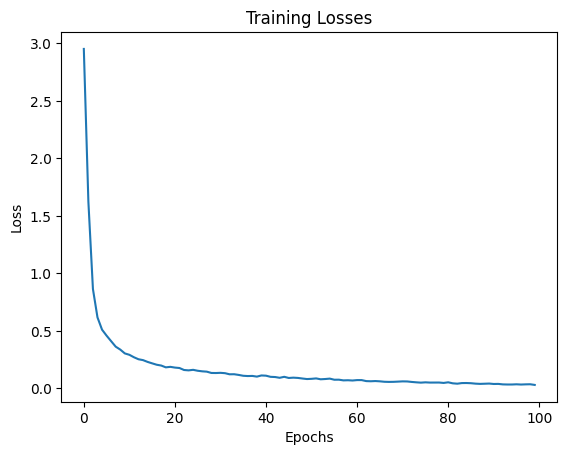

In [106]:
# Plot the Decreasing Loss after Dimension reduction
loss_dt_pca = pd.DataFrame({
    "Training_loss": training_losses
})

plt.plot(
    loss_dt["Training_loss"],
    label="Training_loss"
)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Losses")

plt.savefig(
    "/content/drive/MyDrive/training_loss_PCA.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [107]:
# Model Evaluation after PCA

#Initialize Evaluation state
model.eval()
# Default Total Prediction count & Correct prediction count
total_pred = 0
corr_pred = 0

#Apply no gradient calculation
with torch.no_grad():
  for Xb, yb in testing_loader:
    pred = model(Xb)
    # This prediction will return some tensor val as 0.2, 0.3, 1.3, 2.0, 1.5
    # We want the maximum val as best prediction val
    # Now we want the right category as Output, so we have to take the maxVal's Index No., not the maxVal
    _, predCategory = torch.max(pred, 1) # '_' uses to hide, because maxVal not want, only index(1) want

    corr_pred += (predCategory == yb).sum().item()
    total_pred += yb.size(0)

print(f"Accuracy Score: ", (corr_pred/total_pred) * 100)

Accuracy Score:  68.33333333333333


In [108]:
loss_dt_pca

,Training_loss
0,1.927316
1,1.582069
2,1.206094
3,0.891668
4,0.719794
...,...
95,0.144310
96,0.151868
97,0.145461
98,0.141375


In [109]:
loss_dt

,Training_loss
0,2.952831
1,1.625217
2,0.864882
3,0.617786
4,0.511297
...,...
95,0.036178
96,0.034113
97,0.035684
98,0.036539


In [114]:
# Comparing two model's Training losses

loss_dt.rename(
    columns={"Training_loss": "Loss_Without_PCA"},
    inplace=True
)

loss_dt_pca.rename(
    columns={"Training_loss": "Loss_With_PCA"},
    inplace=True
)

#Merge both DtaFrame
compare_dt = pd.concat([loss_dt, loss_dt_pca], axis=1)

compare_dt

,Loss_Without_PCA,Loss_With_PCA
0,2.952831,1.927316
1,1.625217,1.582069
2,0.864882,1.206094
3,0.617786,0.891668
4,0.511297,0.719794
...,...,...
95,0.036178,0.144310
96,0.034113,0.151868
97,0.035684,0.145461
98,0.036539,0.141375


In [111]:
compare_dt.to_csv(
    "/content/drive/MyDrive/loss_vs_LossPCA.csv",
    index=False
)

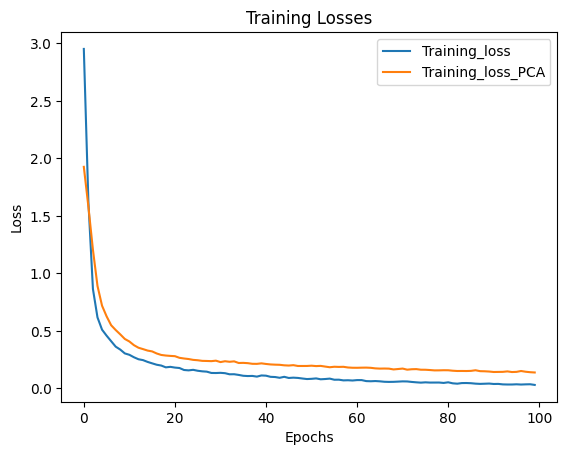

In [115]:
# Plot the Decreasing Loss after Dimension reduction

#Without PCA
plt.plot(
    loss_dt["Loss_Without_PCA"],
    label="Training_loss"
)

#With PCA
plt.plot(
    loss_dt_pca["Loss_With_PCA"],
    label="Training_loss_PCA"
)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Losses")
plt.legend()

plt.savefig(
    "/content/drive/MyDrive/Compare.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [116]:
print(loss_dt.columns)
print(loss_dt_pca.columns)

Index(['Loss_Without_PCA'], dtype='object')
Index(['Loss_With_PCA'], dtype='object')


In [ ]:
# Comparison:
# Although the model with PCA starts with a lower initial training loss than the model without PCA,
# the model without PCA reduces its loss more rapidly as training progresses.
# After sufficient epochs, the without-PCA model achieves the lowest final training loss,
# indicating better convergence and making it the optimal model for this dataset.

# Observation:
# The PCA-based model begins with a lower initial training loss, but its loss decreases more slowly.
# In contrast, the model without PCA eventually achieves a much lower final training loss
# (≈0.03 vs ≈0.15) and also attains a higher test accuracy (93% vs 67%).
# Therefore, the model without PCA performs better overall and is selected as the optimal model.